# A03 - Assurance Outcomes

> **Dados legados.** Este notebook analisa campanhas congeladas, geradas
> com o modelo escalar de fidelidade (`ket_vector`) antes da revisão de
> realismo físico (`docs/physical_model.md`). Os números valem como
> registro do manuscrito V1, não para o modelo físico atual; os resultados
> que o manuscrito V2 usa estão em `results/realistic/`
> (`docs/realistic_results.md`).

## Objetivo
Mostrar a distribuição de `SATISFIED`/`VIOLATED`/`REJECTED` - nenhum
forçado manualmente - em função de atenuação e fidelidade requisitada,
usando os dados reais e já persistidos da campanha
`C03_assurance_outcomes` (8 trials: 2 atenuações x 2 fidelidades x 2
seeds). Este notebook **não roda nenhuma simulação**.

## Conceitos
- `REJECTED`: o `IntentPlanner` já sabia, antes de qualquer simulação, que
  o requisito de fidelidade excede o alcançável (mesmo com purificação).
- `VIOLATED`: o plano era viável na estimativa (fidelidade/memória
  bastavam), mas a simulação real não entregou pares suficientes na
  janela - o planner v1 não estima throughput
  (`docs/limitations.md`).
- `SATISFIED`: plano viável e resultado operacional suficiente.


## Configuração


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from ibqn.experiments.persistence import read_trials_dataframe, trials_csv_path
from ibqn.experiments.export import save_figure, save_table

RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures" / "article"
TABLES_DIR = RESULTS_DIR / "tables" / "article"
CAMPAIGN = "C03_assurance_outcomes"

trials_df = read_trials_dataframe(trials_csv_path(RESULTS_DIR, CAMPAIGN))
trials_df[["attenuation_db_per_m", "requested_fidelity", "seed", "final_status", "delivered_pairs", "violations"]]


,attenuation_db_per_m,requested_fidelity,seed,final_status,delivered_pairs,violations
0,0.00001,0.60,0,SATISFIED,237.0,NaN
1,0.00001,0.60,1,SATISFIED,256.0,NaN
2,0.00001,0.95,0,REJECTED,NaN,no candidate route is feasible: a->r->b (min_f...
3,0.00001,0.95,1,REJECTED,NaN,no candidate route is feasible: a->r->b (min_f...
4,0.02500,0.60,0,VIOLATED,1.0,delivered_pairs >= 10.0 (observed=1.0) -> FAIL
5,0.02500,0.60,1,VIOLATED,1.0,delivered_pairs >= 10.0 (observed=1.0) -> FAIL
6,0.02500,0.95,0,REJECTED,NaN,no candidate route is feasible: a->r->b (min_f...
7,0.02500,0.95,1,REJECTED,NaN,no candidate route is feasible: a->r->b (min_f...


## Execução


In [2]:
status_counts = trials_df["final_status"].value_counts()
print("Status distribution across all 8 trials:")
print(status_counts)

status_by_condition = (
    trials_df.groupby(["attenuation_db_per_m", "requested_fidelity"])["final_status"]
    .apply(lambda s: s.value_counts().to_dict())
)
status_by_condition


Status distribution across all 8 trials:
final_status
REJECTED     4
SATISFIED    2
VIOLATED     2
Name: count, dtype: int64


attenuation_db_per_m  requested_fidelity           
0.00001               0.60                SATISFIED    2.0
                                          REJECTED     NaN
                                          VIOLATED     NaN
                      0.95                SATISFIED    NaN
                                          REJECTED     2.0
                                          VIOLATED     NaN
0.02500               0.60                SATISFIED    NaN
                                          REJECTED     NaN
                                          VIOLATED     2.0
                      0.95                SATISFIED    NaN
                                          REJECTED     2.0
                                          VIOLATED     NaN
Name: final_status, dtype: float64

## Resultados


In [3]:
pivot = trials_df.pivot_table(
    index="attenuation_db_per_m", columns="requested_fidelity", values="final_status",
    aggfunc=lambda statuses: "/".join(sorted(set(statuses))),
)
save_table(pivot.reset_index(), "A03_status_by_attenuation_and_fidelity", directory=TABLES_DIR)
pivot


requested_fidelity,0.60,0.95
attenuation_db_per_m,,
0.00001,SATISFIED,REJECTED
0.02500,VIOLATED,REJECTED


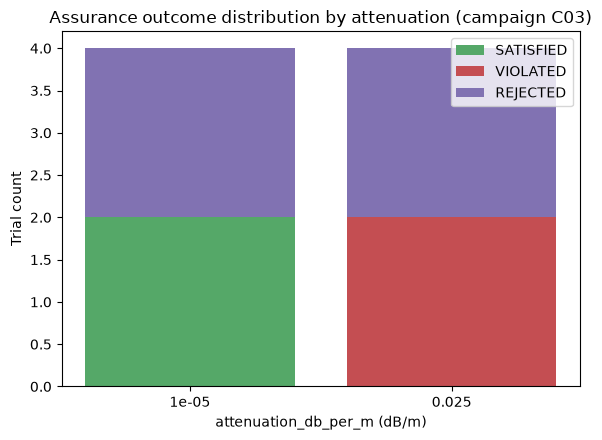

In [4]:
fig, ax = plt.subplots(figsize=(6, 4.5))
status_colors = {"SATISFIED": "#55A868", "VIOLATED": "#C44E52", "REJECTED": "#8172B2"}
bottom = pd.Series(0, index=sorted(trials_df["attenuation_db_per_m"].unique()))
grouped = trials_df.groupby(["attenuation_db_per_m", "final_status"]).size().unstack(fill_value=0)
for status in ["SATISFIED", "VIOLATED", "REJECTED"]:
    if status not in grouped.columns:
        continue
    ax.bar(grouped.index.astype(str), grouped[status], bottom=bottom.reindex(grouped.index, fill_value=0).values,
           label=status, color=status_colors[status])
    bottom = bottom.add(grouped[status], fill_value=0)
ax.set_xlabel("attenuation_db_per_m (dB/m)")
ax.set_ylabel("Trial count")
ax.set_title("Assurance outcome distribution by attenuation (campaign C03)")
ax.legend()
fig.tight_layout()
save_figure(fig, "A03_outcomes_by_attenuation", directory=FIGURES_DIR)
plt.show()


In [5]:
violated_rows = trials_df[trials_df["final_status"] == "VIOLATED"]
print("Violation reasons for every VIOLATED trial:")
for _, row in violated_rows.iterrows():
    print(f"  seed={row['seed']}, attenuation={row['attenuation_db_per_m']}: {row['violations']}")


Violation reasons for every VIOLATED trial:
  seed=0, attenuation=0.025: delivered_pairs >= 10.0 (observed=1.0) -> FAIL
  seed=1, attenuation=0.025: delivered_pairs >= 10.0 (observed=1.0) -> FAIL


In [6]:
assert set(trials_df["final_status"].unique()) == {"SATISFIED", "VIOLATED", "REJECTED"}, (
    "campaign C03 must naturally produce all three terminal statuses"
)
low_atten_low_fidelity = trials_df[(trials_df["attenuation_db_per_m"] < 0.001) & (trials_df["requested_fidelity"] < 0.9)]
high_atten_low_fidelity = trials_df[(trials_df["attenuation_db_per_m"] > 0.001) & (trials_df["requested_fidelity"] < 0.9)]
high_fidelity = trials_df[trials_df["requested_fidelity"] > 0.9]
assert (low_atten_low_fidelity["final_status"] == "SATISFIED").all()
assert (high_atten_low_fidelity["final_status"] == "VIOLATED").all()
assert (high_fidelity["final_status"] == "REJECTED").all()
print("Confirmed: SATISFIED/VIOLATED/REJECTED each occur exactly where the physics predicts, never forced.")


Confirmed: SATISFIED/VIOLATED/REJECTED each occur exactly where the physics predicts, never forced.


## Interpretação
Baixa atenuação + fidelidade alcançável -> `SATISFIED`. Alta atenuação
(mesma fidelidade alcançável) -> `VIOLATED`: a fidelidade continua
~0.6864 (atenuação não afeta fidelidade, só a probabilidade de perda de
fóton), mas o throughput cai o suficiente para não entregar os pares
pedidos na janela. Fidelidade requisitada acima do teto alcançável (0.95)
-> `REJECTED` **independentemente** da atenuação, porque a rejeição
acontece no planejamento, antes de qualquer efeito da atenuação entrar em
jogo.

## Limitações
- `n=2` seeds por condição - descritivo (`docs/campaign_architecture.md`).
- `reserved_memory_slots`/`duration_s` fixos nesta campanha (ver a
  descrição de `C03_assurance_outcomes.yaml` sobre por que não foram
  varridos aqui: `validation.success_conditions` são declaradas
  independentemente de `requirements`, então variar
  `reserved_memory_slots` sem variar a condição de sucesso correspondente
  não testaria o que esta campanha precisa testar).

## Conclusão
Os três status terminais mais comuns produzidos naturalmente, sem forçar
nenhum, e sua ocorrência corresponde exatamente ao que a física do
simulador prediz.
